# セル1 : ライブラリのインポートとバージョン確認

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from importlib import metadata

# ライブラリのバージョンを確認
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Polars Version: {pl.__version__}")
print(f"PyArrow Version: {pa.__version__}")
print(f"Matplotlib Version: {plt.matplotlib.__version__}")
print(f"Seaborn Version: {sns.__version__}")
print(f"Plotly Version: {metadata.version('plotly')}")
print(f"Scikit-learn Version: {metadata.version('scikit-learn')}")
print("\n--- 全てのライブラリのインポートに成功しました！ ---")

Pandas Version: 2.3.3
NumPy Version: 2.3.4
Polars Version: 1.35.1
PyArrow Version: 22.0.0
Matplotlib Version: 3.10.7
Seaborn Version: 0.13.2
Plotly Version: 6.3.1
Scikit-learn Version: 1.7.2

--- 全てのライブラリのインポートに成功しました！ ---


# セル2 : データ生成とNumpy/Pandas/Polarsによるデータ処理

In [6]:
# 1. NumPyでデータ生成
np.random.seed(42)
data_len = 100
X = np.random.rand(data_len) * 10
y = 2 * X + 1 + np.random.randn(data_len) * 2

# 2. Pandas DataFrameの作成
df_pandas = pd.DataFrame({"Feature_X": X, "Target_Y": y})
df_pandas["Category"] = np.random.choice(["A", "B", "C"], data_len)

print("--- Pandas DataFrameの確認 (NumPyデータから生成) ---")
print(df_pandas.head())
print(f"\nデータ型の確認:\n{df_pandas.dtypes}")

# 3. Polars DataFrameへの変換とPyArrowの活用
# Polarsは内部でPyArrowを多く利用するため、間接的にPyArrowのテストにもなる
df_polars = pl.from_pandas(df_pandas)

# Polarsでの集計処理 (Group By)
df_summary = df_polars.group_by("Category").agg(
    pl.mean("Target_Y").alias("Mean_Y"), pl.len().alias("Count")
)

print("\n--- Polarsでの集計結果 ---")
print(df_summary)

--- Pandas DataFrameの確認 (NumPyデータから生成) ---
   Feature_X   Target_Y Category
0   3.745401   8.664897        B
1   9.507143  19.416271        A
2   7.319939  15.823400        B
3   5.986585   8.998032        A
4   1.560186   3.681029        C

データ型の確認:
Feature_X    float64
Target_Y     float64
Category      object
dtype: object

--- Polarsでの集計結果 ---
shape: (3, 3)
┌──────────┬───────────┬───────┐
│ Category ┆ Mean_Y    ┆ Count │
│ ---      ┆ ---       ┆ ---   │
│ str      ┆ f64       ┆ u32   │
╞══════════╪═══════════╪═══════╡
│ B        ┆ 12.087775 ┆ 36    │
│ C        ┆ 9.002602  ┆ 29    │
│ A        ┆ 9.826002  ┆ 35    │
└──────────┴───────────┴───────┘


# 3 : MatplotlibとSeabornによる静的な可視化

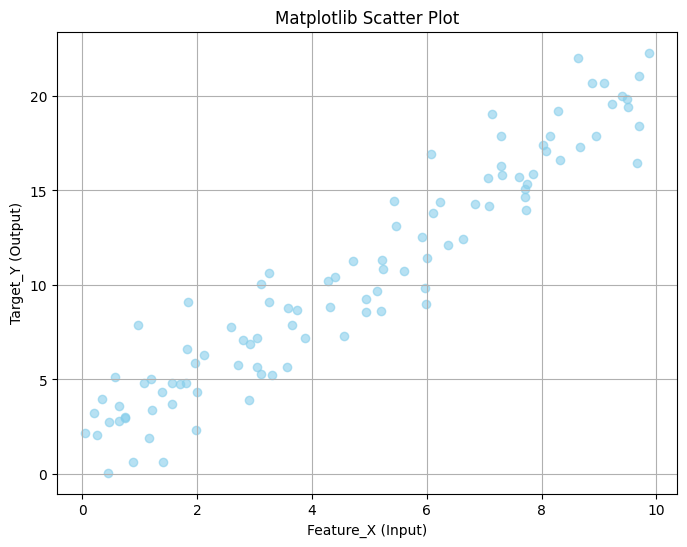

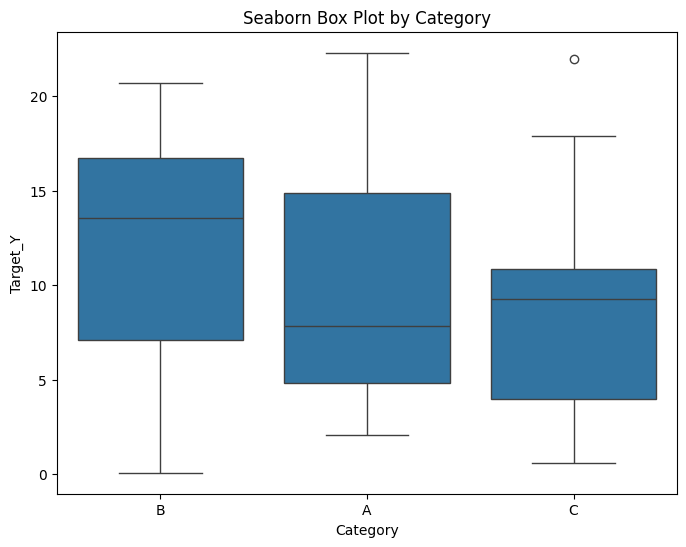


--- MatplotlibとSeabornによる可視化に成功しました！ ---


In [ ]:
# Matplotlibのバックエンド設定 (Notebookで表示するために重要)
%matplotlib inline

# 1. Matplotlibで散布図を作成
plt.figure(figsize=(8, 6))
plt.scatter(df_pandas["Feature_X"], df_pandas["Target_Y"], alpha=0.6, color="skyblue")
plt.title("Matplotlib Scatter Plot")
plt.xlabel("Feature_X (Input)")
plt.ylabel("Target_Y (Output)")
plt.grid(True)
plt.show()

# 2. Seabornで箱ひげ図を作成 (カテゴリ別のYの分布確認)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Category", y="Target_Y", data=df_pandas)
plt.title("Seaborn Box Plot by Category")
plt.xlabel("Category")
plt.ylabel("Target_Y")
plt.show()

print("\n--- MatplotlibとSeabornによる可視化に成功しました！ ---")

# 4 : Plotlyによる対話型可視化

In [ ]:
# Plotlyでインタラクティブな散布図を作成
fig = px.scatter(
    df_pandas,
    x="Feature_X",
    y="Target_Y",
    color="Category",
    title="Plotly Interactive Scatter Plot",
    hover_data=["Feature_X", "Target_Y"],
)

# Notebookでの表示
fig.show()

print("--- Plotlyによる対話型可視化に成功しました！ ---")

--- Plotlyによる対話型可視化に成功しました！ ---


# 5 : Scikit-learnによる機械学習の基礎テスト

In [ ]:
# 1. データの準備
X_model = df_pandas[["Feature_X"]].values
y_model = df_pandas["Target_Y"].values

# 2. 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.3, random_state=42
)

# 3. モデルのインスタンス化と学習（線形回帰）
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 予測と評価
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("--- Scikit-learnによる線形回帰テスト ---")
print(f"モデルの係数 (Slope): {model.coef_[0]:.2f}")
print(f"切片 (Intercept): {model.intercept_:.2f}")
print(f"平均二乗誤差 (MSE) on Test Data: {mse:.2f}")

print("\n--- 全てのライブラリを利用した環境テストが完了しました！ ---")

--- Scikit-learnによる線形回帰テスト ---
モデルの係数 (Slope): 1.91
切片 (Intercept): 1.24
平均二乗誤差 (MSE) on Test Data: 2.52

--- 全てのライブラリを利用した環境テストが完了しました！ ---


上記の**平均二乗誤差 (Mean Squared Error, MSE)**を定義する数式は、Markdown内で以下のようにLaTeXで表現されます。

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 $$ここで、 * $n$ はデータ点の総数。 * $Y_i$ は $i$ 番目のデータ点の**実際値**（真の値）。 * $\hat{Y}_i$ は $i$ 番目のデータ点の**予測値**。 ----- ### 3\. インライン数式とリスト **勾配降下法**の更新ステップを表現すると、以下のようになります。 パラメータ $\theta$ の更新式は $\theta := \theta - \alpha \nabla J(\theta)$ です。ここで、$\alpha$ は\*\*学習率 (learning rate)\*\*と呼ばれます。 **重要なライブラリの要件:** * **Pandas** のバージョン: $\ge 2.3.0$ * **NumPy** の要件: $\ge 2.3.0$ * **Polars** の高速化: Apache Arrow (PyArrow) の利用 ----- これで、Markdown、Pythonコードブロック、そしてLaTeXの数式表示がすべて正しくレンダリングされるか確認できます。$$